In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv(
    "../../01_original_data/federal_housing_finance_agency/hpi_master.csv",
    index_col=False,
)

# Display basic info
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:\n", df.head())

Shape: (131520, 10)

Data Types:
 hpi_type       object
hpi_flavor     object
frequency      object
level          object
place_name     object
place_id       object
yr              int64
period          int64
index_nsa     float64
index_sa      float64
dtype: object

First 5 Rows:
       hpi_type     hpi_flavor frequency                   level  \
0  traditional  purchase-only   monthly  USA or Census Division   
1  traditional  purchase-only   monthly  USA or Census Division   
2  traditional  purchase-only   monthly  USA or Census Division   
3  traditional  purchase-only   monthly  USA or Census Division   
4  traditional  purchase-only   monthly  USA or Census Division   

                    place_name place_id    yr  period  index_nsa  index_sa  
0  East North Central Division   DV_ENC  1991       1     100.00    100.00  
1  East North Central Division   DV_ENC  1991       2     100.87    100.87  
2  East North Central Division   DV_ENC  1991       3     101.33    100.90  
3  Ea

In [14]:
df["place_id"] = pd.to_numeric(df["place_id"], errors="coerce")
fhfa_msa = df[df["place_id"].notna()].reset_index(drop=True)
fhfa_msa

,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa
0,traditional,all-transactions,quarterly,MSA,"Abilene, TX",10180.0,1986,2,108.04,NaN
1,traditional,all-transactions,quarterly,MSA,"Abilene, TX",10180.0,1986,3,108.27,NaN
2,traditional,all-transactions,quarterly,MSA,"Abilene, TX",10180.0,1986,4,94.80,NaN
3,traditional,all-transactions,quarterly,MSA,"Abilene, TX",10180.0,1987,1,101.62,NaN
4,traditional,all-transactions,quarterly,MSA,"Abilene, TX",10180.0,1987,2,100.88,NaN
...,...,...,...,...,...,...,...,...,...,...
92040,distress-free,purchase-only,quarterly,MSA,"Warren-Troy-Farmington Hills, MI (MSAD)",47664.0,2024,2,355.22,347.52
92041,distress-free,purchase-only,quarterly,MSA,"Warren-Troy-Farmington Hills, MI (MSAD)",47664.0,2024,3,356.51,351.59
92042,distress-free,purchase-only,quarterly,MSA,"Warren-Troy-Farmington Hills, MI (MSAD)",47664.0,2024,4,353.33,355.15
92043,distress-free,purchase-only,quarterly,MSA,"Warren-Troy-Farmington Hills, MI (MSAD)",47664.0,2025,1,362.54,362.63


In [ ]:
fhfa_msa_grouped = (
    fhfa_msa.groupby(["place_id", "yr"])
    .sum(["index_nsa", "index_sa"])
    .reset_index()
    .join(
        fhfa_msa[["place_id", "place_name"]].drop_duplicates().set_index("place_id"),
        on="place_id",
        how="left",
    )
)
fhfa_msa_grouped

,place_id,yr,period,index_nsa,index_sa,place_name
0,10180.0,1986,9,311.11,0.0,"Abilene, TX"
1,10180.0,1987,10,391.79,0.0,"Abilene, TX"
2,10180.0,1988,10,338.28,0.0,"Abilene, TX"
3,10180.0,1989,10,330.32,0.0,"Abilene, TX"
4,10180.0,1990,10,323.57,0.0,"Abilene, TX"
...,...,...,...,...,...,...
17729,49740.0,2021,10,997.46,0.0,"Yuma, AZ"
17730,49740.0,2022,10,1211.43,0.0,"Yuma, AZ"
17731,49740.0,2023,10,1257.80,0.0,"Yuma, AZ"
17732,49740.0,2024,10,1324.62,0.0,"Yuma, AZ"


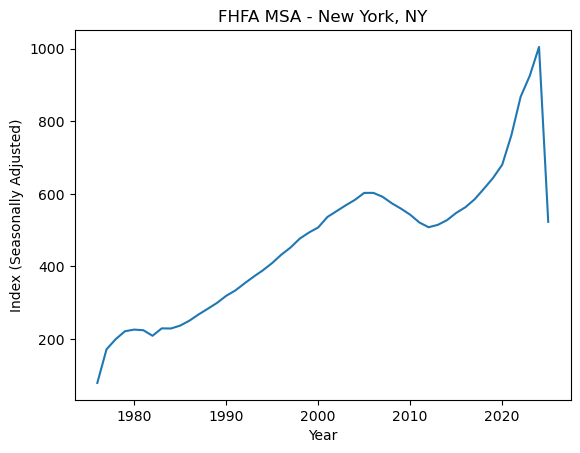

In [16]:
sns.lineplot(
    data=fhfa_msa_grouped[fhfa_msa_grouped["place_name"] == "Akron, OH"],
    x="yr",
    y="index_nsa",
)
plt.title("FHFA MSA - New York, NY")
plt.xlabel("Year")
plt.ylabel("Index (Seasonally Adjusted)")
plt.show()

In [ ]:
fhfa_msa_grouped_place = (
    fhfa_msa_grouped.groupby(
        ["yr", "place_id"], as_index=False
    )  # [["index_nsa", "index_sa"]].sum()
    .sum(["index_nsa", "index_sa"])
    .reset_index(drop=True)
    .join(
        fhfa_msa[["place_id", "place_name"]].drop_duplicates().set_index("place_id"),
        on="place_id",
        how="left",
    )
    .sort_values(by=["index_nsa"], ascending=False)
)
fhfa_msa_grouped_place

,yr,place_id,period,index_nsa,index_sa,place_name
17151,2024,33124.0,40,11529.10,8966.35,"Miami-Miami Beach-Kendall, FL (MSAD)"
16741,2023,33124.0,40,10472.63,8155.19,"Miami-Miami Beach-Kendall, FL (MSAD)"
16331,2022,33124.0,40,9362.45,7297.09,"Miami-Miami Beach-Kendall, FL (MSAD)"
17200,2024,38060.0,40,9114.64,7071.99,"Phoenix-Mesa-Chandler, AZ"
16380,2022,38060.0,40,8749.50,6806.77,"Phoenix-Mesa-Chandler, AZ"
...,...,...,...,...,...,...
12,1975,41740.0,4,25.28,0.00,"San Diego-Chula Vista-Carlsbad, CA"
63,1976,42220.0,4,25.17,0.00,"Santa Rosa-Petaluma, CA"
9,1975,35614.0,4,24.00,0.00,"New York-Jersey City-White Plains, NY-NJ (MSAD)"
23,1976,15764.0,4,23.43,0.00,"Cambridge-Newton-Framingham, MA (MSAD)"


In [75]:
max(data_to_plot["yr"])

2024

/var/folders/d6/ctkwr8y15b3fjbrsjdbc2zt80000gn/T/ipykernel_93271/1481514832.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_to_plot = fhfa_msa_grouped_place[fhfa_msa_grouped_place["yr"] <= 2024][


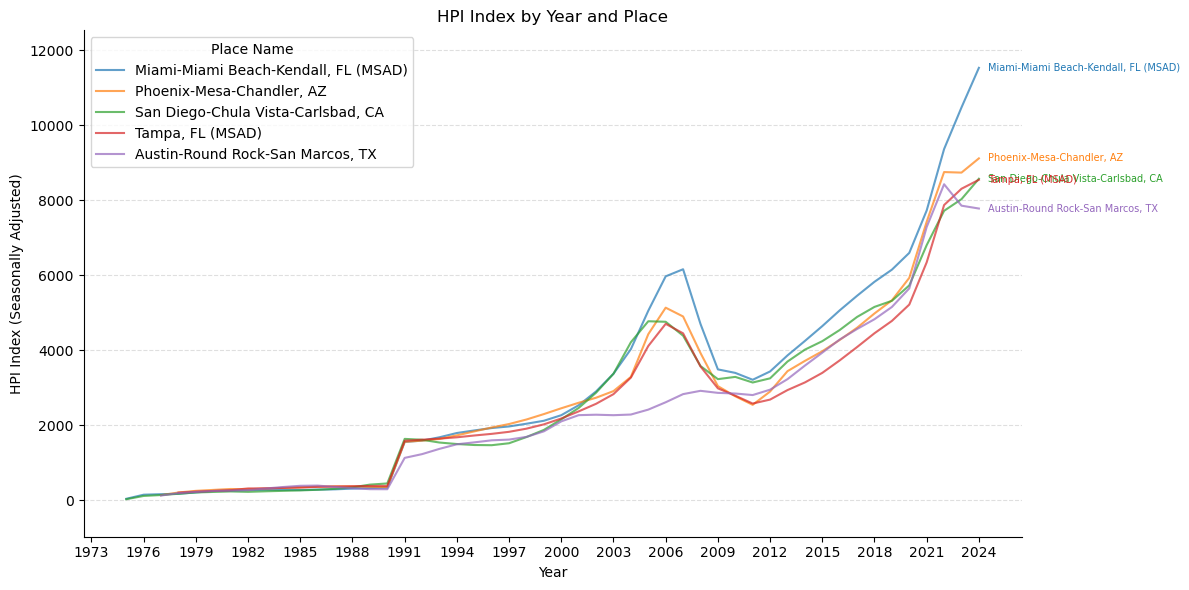

,yr,place_id,period,index_nsa,index_sa,place_name
17151,2024,33124.0,40,11529.10,8966.35,"Miami-Miami Beach-Kendall, FL (MSAD)"
16741,2023,33124.0,40,10472.63,8155.19,"Miami-Miami Beach-Kendall, FL (MSAD)"
16331,2022,33124.0,40,9362.45,7297.09,"Miami-Miami Beach-Kendall, FL (MSAD)"
17200,2024,38060.0,40,9114.64,7071.99,"Phoenix-Mesa-Chandler, AZ"
16380,2022,38060.0,40,8749.50,6806.77,"Phoenix-Mesa-Chandler, AZ"
...,...,...,...,...,...,...
129,1977,38060.0,9,132.76,0.00,"Phoenix-Mesa-Chandler, AZ"
74,1977,12420.0,9,123.55,0.00,"Austin-Round Rock-San Marcos, TX"
59,1976,41740.0,10,113.10,0.00,"San Diego-Chula Vista-Carlsbad, CA"
7,1975,33124.0,4,36.87,0.00,"Miami-Miami Beach-Kendall, FL (MSAD)"


In [ ]:
# Scatter: year vs amount, colored by place_id
data_to_plot = fhfa_msa_grouped_place[fhfa_msa_grouped_place["yr"] <= 2024][
    fhfa_msa_grouped_place["place_id"].isin(
        fhfa_msa_grouped_place[fhfa_msa_grouped_place["yr"].isin(range(2015, 2025))]
        .nlargest(10, "index_nsa")["place_id"]
        .values
    )
]
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=data_to_plot,
    x="yr",
    y="index_nsa",  # replace with your column, e.g., "index_nsa"
    hue="place_name",
    alpha=0.7,
)

plt.title("HPI Index by Year and Place")
plt.xlabel("Year")
plt.ylabel("HPI Index (Seasonally Adjusted)")
plt.legend(title="Place ID", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.ylim(min(data_to_plot["index_nsa"]) - 1000, max(data_to_plot["index_nsa"]) + 1000)
plt.xticks(range(min(data_to_plot["yr"]) - 2, max(data_to_plot["yr"]) + 1, 3))

plt.grid(True, axis="y", linestyle="--", alpha=0.4)
ax = plt.gca()
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# plt.xticks(rotation=45, ha="right")

# # Add text labels at the end of each line
# for line, name in zip(ax.lines, data_to_plot["place_name"].unique()):
#     y = line.get_ydata()[-1]  # last y-value
#     x = line.get_xdata()[-1]  # last x-value
#     ax.text(x + 0.5, y, name, color=line.get_color(), va="center", fontsize=7)

plt.legend(title="Place Name")

plt.tight_layout()
plt.show()
data_to_plot

/var/folders/d6/ctkwr8y15b3fjbrsjdbc2zt80000gn/T/ipykernel_93271/2767389642.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_to_plot_min = fhfa_msa_grouped_place[fhfa_msa_grouped_place["yr"] <= 2024][


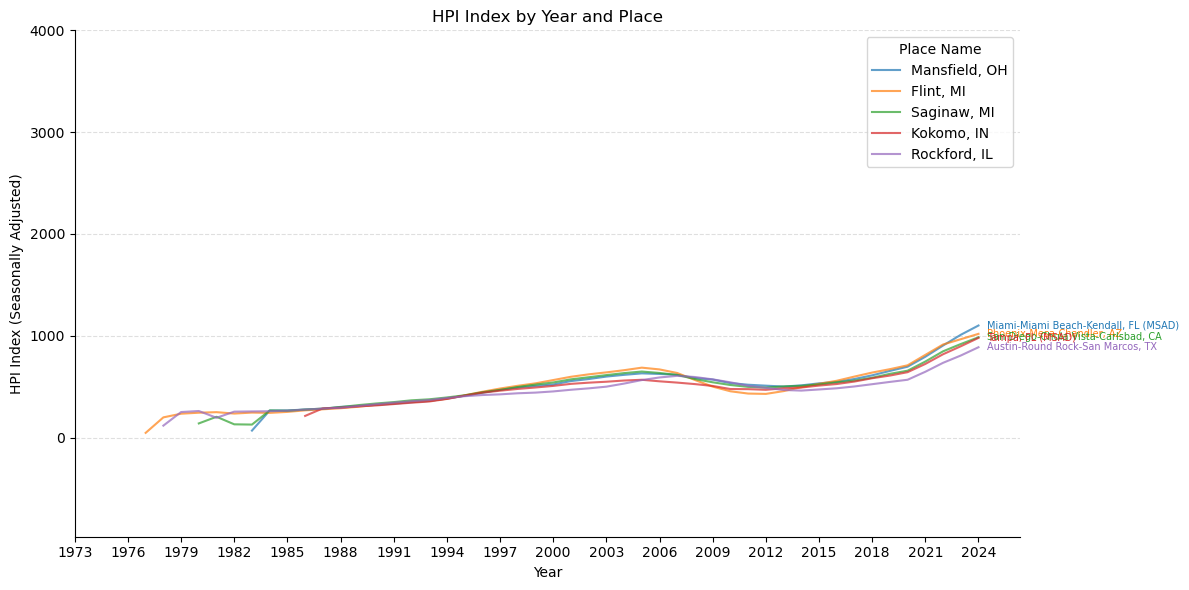

,yr,place_id,period,index_nsa,index_sa,place_name
17151,2024,33124.0,40,11529.10,8966.35,"Miami-Miami Beach-Kendall, FL (MSAD)"
16741,2023,33124.0,40,10472.63,8155.19,"Miami-Miami Beach-Kendall, FL (MSAD)"
16331,2022,33124.0,40,9362.45,7297.09,"Miami-Miami Beach-Kendall, FL (MSAD)"
17200,2024,38060.0,40,9114.64,7071.99,"Phoenix-Mesa-Chandler, AZ"
16380,2022,38060.0,40,8749.50,6806.77,"Phoenix-Mesa-Chandler, AZ"
...,...,...,...,...,...,...
129,1977,38060.0,9,132.76,0.00,"Phoenix-Mesa-Chandler, AZ"
74,1977,12420.0,9,123.55,0.00,"Austin-Round Rock-San Marcos, TX"
59,1976,41740.0,10,113.10,0.00,"San Diego-Chula Vista-Carlsbad, CA"
7,1975,33124.0,4,36.87,0.00,"Miami-Miami Beach-Kendall, FL (MSAD)"


In [ ]:
# Scatter: year vs amount, colored by place_id
data_to_plot_min = fhfa_msa_grouped_place[fhfa_msa_grouped_place["yr"] <= 2024][
    fhfa_msa_grouped_place["place_id"].isin(
        fhfa_msa_grouped_place[fhfa_msa_grouped_place["yr"].isin(range(2015, 2025))]
        .nsmallest(9, "index_nsa")["place_id"]
        .values
    )
]
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=data_to_plot_min,
    x="yr",
    y="index_nsa",  # replace with your column, e.g., "index_nsa"
    hue="place_name",
    alpha=0.7,
)

plt.title("HPI Index by Year and Place")
plt.xlabel("Year")
plt.ylabel("HPI Index (Seasonally Adjusted)")
plt.legend(title="Place ID", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.ylim(min(data_to_plot["index_nsa"]) - 1000, 4000)
plt.xticks(range(min(data_to_plot["yr"]) - 2, max(data_to_plot["yr"]) + 1, 3))

plt.grid(True, axis="y", linestyle="--", alpha=0.4)
ax = plt.gca()
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# plt.xticks(rotation=45, ha="right")

# # Add text labels at the end of each line
# for line, name in zip(ax.lines, data_to_plot["place_name"].unique()):
#     y = line.get_ydata()[-1]  # last y-value
#     x = line.get_xdata()[-1]  # last x-value
#     ax.text(x + 0.5, y, name, color=line.get_color(), va="center", fontsize=7)

plt.legend(title="Place Name")

plt.tight_layout()
plt.show()
data_to_plot

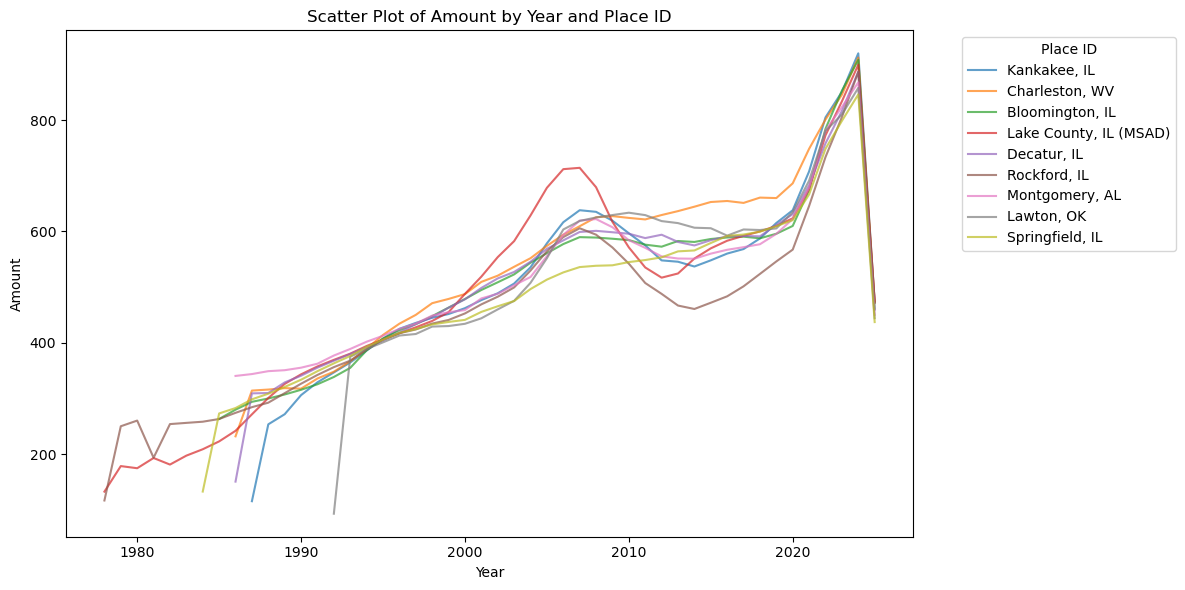

In [ ]:
# Scatter: year vs amount, colored by place_id
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=fhfa_msa_grouped_place[
        fhfa_msa_grouped_place["place_id"].isin(
            fhfa_msa_grouped_place[fhfa_msa_grouped_place["yr"] >= 2015]
            .nsmallest(10, "index_nsa")["place_id"]
            .values
        )
    ],
    x="yr",
    y="index_nsa",  # replace with your column, e.g., "index_nsa"
    hue="place_name",
    alpha=0.7,
)

plt.title("Scatter Plot of Amount by Year and Place ID")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend(title="Place ID", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()